In [1]:
%set_env TOKENIZERS_PARALLELISM=false
import os
import numpy as np
import torch
torch._dynamo.config.suppress_errors = True

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

from esm.utils.structure.protein_chain import ProteinChain
from esm.utils.constants.esm3 import SEQUENCE_VOCAB
from esm.models.esm3 import ESM3
from esm.sdk.api import (
    ESMProtein,
    GenerationConfig,
)

model =  ESM3.from_pretrained("esm3_sm_open_v1", device=torch.device(DEVICE)).eval()

env: TOKENIZERS_PARALLELISM=false


Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

In [2]:
from esm.pretrained import (
    ESM3_function_decoder_v0,
    ESM3_sm_open_v0,
    ESM3_structure_decoder_v0,
)
from esm.tokenization.function_tokenizer import (
    InterProQuantizedTokenizer as EsmFunctionTokenizer,
)
from esm.tokenization.sequence_tokenizer import (
    EsmSequenceTokenizer,
)
from esm.utils.constants.esm3 import (
    SEQUENCE_MASK_TOKEN,
)
from esm.utils.structure.protein_chain import ProteinChain
from esm.utils.types import FunctionAnnotation

tokenizer = EsmSequenceTokenizer()
function_tokenizer = EsmFunctionTokenizer()


In [3]:
sequence = "MKTFIFLALLGAAVAFPVDDDDKIVGGYTCGANTVPYQVSLNSGYHFCGGSLINSQWVVSAAHCYKSGIQVRLGEDNINVVEGNEQFISASKSIVHPSYNSNTL"
sequence = "MKTFIFLALLG"
protein_prompt = ESMProtein(sequence=sequence)
protein_tensor = model.encode(protein_prompt)
len(sequence), protein_tensor.sequence.shape

(11, torch.Size([13]))

In [4]:
def get_logits_reference(seq, function_tokens=None, batch_size=1):
  protein_prompt = ESMProtein(sequence=seq)
  protein_tensor = model.encode(protein_prompt)
  x, ln = protein_tensor.sequence, len(seq)
  with torch.no_grad():
    f = lambda x: model(sequence_tokens=x, function_tokens=function_tokens).sequence_logits[:, 1:(ln+1), 4:24].detach().cpu().numpy()
    logits = np.zeros((ln, 20), dtype=np.float32)
    for n in range(0, ln, batch_size):
        m = min(n + batch_size, ln)
        x_h = torch.clone(x).unsqueeze(0).repeat(m - n, 1)
        for i in range(m - n):
            x_h[i, n + i + 1] = SEQUENCE_VOCAB.index("<mask>")
        fx_h = f(x_h.to(DEVICE))
        for i in range(m - n):
            logits[n + i] = fx_h[i, n + i]
  return logits

In [44]:
def mask_perc(seq_ind, mask_token, residue_coverage=6, mut_per=0.15):
    device = seq_ind.device
    seq_len = torch.LongTensor([seq_ind.shape[0] - 2]).to(device) #Discount SOS and EOS tokens at start and end
    mut_count = torch.floor(seq_len*mut_per).int().item()
    total_muts = (torch.floor(seq_len*residue_coverage/mut_count)*mut_count).int().item()
    
    mut_inds = (torch.randperm(total_muts).reshape(-1, mut_count).to(device) % seq_len) + 1
    batch_inds = torch.tile(torch.arange(0, mut_inds.shape[0]).reshape((-1, 1)), (1, mut_count))
    mut_inds, batch_inds = mut_inds.to(device), batch_inds.to(device)

    batch = torch.tile(seq_ind, (mut_inds.shape[0], 1))
    batch[batch_inds, mut_inds] = mask_token
    # print((batch==mask_token).sum())
    return batch, batch_inds, mut_inds

def mask_indiv(seq_ind, mask_token):
    seq_len = seq_ind.shape[0] - 2 #Discount first and last tokens
    batch = torch.tile(seq_ind, (seq_len, 1))
    batch_ind = torch.arange(seq_len) 
    mut_ind = batch_ind + 1
    batch[batch_ind, mut_ind] = mask_token
    return batch, batch_ind, mut_ind

def mask_indiv_neighborhood(seq_ind, mask_token, n_rad=5):
    seq_len = seq_ind.shape[0] - 2 #Discount first and last tokens
    batch = torch.tile(seq_ind, (seq_len, 1))
    batch_ind = torch.arange(seq_len)
    mut_ind = batch_ind + 1
    col_ind = torch.arange(seq_ind.shape[0]).reshape(1, -1)
    col_ind = torch.tile(col_ind, (seq_len, 1))
    mut_delta = mut_ind.reshape(-1, 1) - col_ind
    mut_mask = torch.abs(mut_delta) <= n_rad
    mut_mask[:, 0] = False; mut_mask[:, -1] = False #Don't mess with sos, eos tokens
    batch[mut_mask] = mask_token
    return batch, batch_ind, mut_ind

def mask_avg(bert_mask, bert_eval):
    eval_idx = torch.nonzero(bert_mask) ##Nonzero x 2(ij)
    eval_support = torch.sum(bert_mask, dim=0)
    eval_samples = bert_eval[eval_idx[:, 0], eval_idx[:, 1], :]
    eval_avg = torch.zeros_like(bert_eval[0])
    gather_ind = torch.tile(eval_idx[:, 1:2], (1, bert_eval.shape[-1]))
    eval_avg = eval_avg.scatter_reduce(0, gather_ind, eval_samples, 'mean', include_self=False)
    return eval_avg, eval_support

def get_logits(seq, function_tokens=None, batch_size=8, mask_func=mask_indiv):
    protein_prompt = ESMProtein(sequence=seq)
    protein_tensor = model.encode(protein_prompt)
    seq_ind, ln = protein_tensor.sequence, len(seq)
    attention_mask = torch.ones_like(seq_ind).float()
    batch, batch_inds, mut_inds = mask_func(seq_ind, SEQUENCE_MASK_TOKEN)
    bert_mask = (batch == SEQUENCE_MASK_TOKEN)
    bert_eval_l = []
    with torch.no_grad():
        for si in range(0, batch.shape[0], batch_size):
            ei = min(batch.shape[0], si+batch_size)
            x = batch[si:ei, :]
            model_eval = model(sequence_tokens=x, function_tokens=function_tokens)
            bert_eval = model_eval.sequence_logits
            bert_eval_l.append(bert_eval)
    bert_eval = torch.cat(bert_eval_l)
    # bert_eval = torch.softmax(bert_eval, dim=2)
    eval_avg, eval_support = mask_avg(bert_mask, bert_eval)
    return eval_avg, eval_support

def get_unmasked_logits(seq, function_tokens=None):
    protein_prompt = ESMProtein(sequence=seq)
    protein_tensor = model.encode(protein_prompt)
    seq_ind, ln = protein_tensor.sequence.reshape(1, -1), len(seq)
    with torch.no_grad():
        model_eval = model(sequence_tokens=seq_ind, function_tokens=function_tokens)
    return model_eval.sequence_logits[0]

In [29]:
sequence = "MKTFIFLALLGAAVAFPVDDDDKIVGGYTCGANTVPYQVSLNSGYHFCGGSLINSQWVVSAAHCYKSGIQVRLGEDNINVVEGNEQFISASKSIVHPSYNSNTL"
protein_prompt = ESMProtein(sequence=sequence)
protein_tensor = model.encode(protein_prompt)

logits_indiv, logit_support = get_logits(sequence, mask_func=mask_indiv)
logits_indiv = logits_indiv[1:-1, 4:24].cpu().numpy()

logits_nm, logit_support = get_logits(sequence, mask_func=lambda a, b: mask_indiv_neighborhood(a, b, n_rad=3))
logits_nm = logits_nm[1:-1, 4:24].cpu().numpy()

logits_perc, logit_support = get_logits(sequence, mask_func=lambda a, b: mask_perc(a, b, 6, 0.15))
logits_perc = logits_perc[1:-1, 4:24].cpu().numpy()

unmasked_logits = get_unmasked_logits(sequence)
unmasked_logits = unmasked_logits[1:-1, 4:24].cpu().numpy()

reference_logits = get_logits_reference(sequence)

tensor(578, device='cuda:0')


In [59]:
import pandas as pd
from scipy.special import softmax
import matplotlib.pyplot as plt
import bokeh as bh
import bokeh.plotting
bokeh.io.output_notebook()

esm_alphabet = SEQUENCE_VOCAB[4:24]
ALPHABET = "AFILVMWYDEKRHNQSTGPC"
ALPHABET_map = [esm_alphabet.index(a) for a in ALPHABET]
def pssm_to_dataframe(pssm, esm_alphabet):
    sequence_length = pssm.shape[0]
    idx = [str(i) for i in np.arange(1, sequence_length + 1)]
    df = pd.DataFrame(pssm, index=idx, columns=list(esm_alphabet))
    df = df.stack().reset_index()
    df.columns = ['Position', 'Amino Acid', 'Probability']
    return df

def get_pssm_display(sequence, logits):
    pssm_df = pssm_to_dataframe(softmax(logits, axis=-1), ALPHABET)
    num_colors = 256  # You can adjust this number
    palette = bh.palettes.viridis(256)
    TOOLS = "hover,save,pan,box_zoom,reset,wheel_zoom"
    p = bh.plotting.figure(title="CONSERVATION",
            x_range=[str(x) for x in range(1,len(sequence)+1)],
            y_range=list(ALPHABET)[::-1],
            width=900, height=400,
            tools=TOOLS, toolbar_location='below',
            tooltips=[('Position', '@Position'), ('Amino Acid', '@{Amino Acid}'), ('Probability', '@Probability')])

    r = p.rect(x="Position", y="Amino Acid", width=1, height=1, source=pssm_df,
            fill_color=bh.transform.linear_cmap('Probability', palette, low=0, high=1),
            line_color=None)
    p.xaxis.visible = False  # Hide the x-axis
    return p

Loading BokehJS ...

In [65]:
logits_nm, logit_support = get_logits(sequence, mask_func=lambda a, b: mask_indiv_neighborhood(a, b, n_rad=5))
logits_nm = logits_nm[1:-1, 4:24].cpu().numpy()

In [66]:
bh.plotting.show(get_pssm_display(sequence, unmasked_logits))
bh.plotting.show(get_pssm_display(sequence, reference_logits))
bh.plotting.show(get_pssm_display(sequence, logits_nm))



In [ ]:
logits_perc_l = []
for c in range(1, 10):
    logits_perc, logit_support = get_logits(sequence, mask_func=lambda a, b: mask_perc(a, b, c, 0.15))
    logits_perc = logits_perc[1:-1, 4:24].cpu().numpy()
    logits_perc_l.append(logits_perc)

logits_nc_l = []
for c in range(1, 10):
    logits_nc, logit_support = get_logits(sequence, mask_func=lambda a, b: mask_indiv_neighborhood(a, b, c))
    logits_nc = logits_nc[1:-1, 4:24].cpu().numpy()
    logits_nc_l.append(logits_nc)

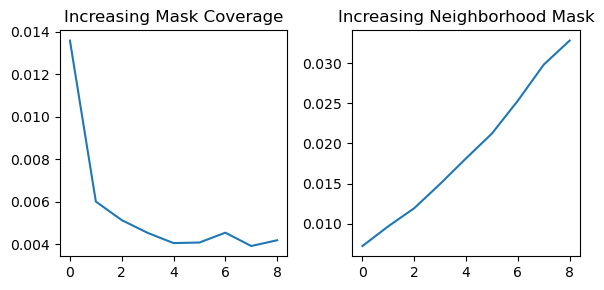

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].set_title('Increasing Mask Coverage'); ax[1].set_title('Increasing Neighborhood Mask')
ax[0].plot([np.abs(softmax(lp, axis=-1) - softmax(reference_logits, axis=-1)).mean() for lp in logits_perc_l])
ax[1].plot([np.abs(softmax(lp, axis=-1) - softmax(reference_logits, axis=-1)).mean() for lp in logits_nc_l])
fig.tight_layout()
fig.show()

In [79]:
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)

import goatools
from goatools.obo_parser import GODag
from goatools.godag.go_tasks import get_go2parents
godag = GODag('../go-basic.obo')
go2parents_isa = get_go2parents(godag, set())
def get_ancestors(go, go2parents):
    seen = set()
    b = {go}
    while b:
        next_term = b.pop()
        if(next_term in seen or not next_term in go2parents):
            continue
        seen.add(next_term)
        b.update(go2parents[next_term])
        # print(b)
    return seen

from go_ml.train_utils import get_enzyme_df, enzyme_iterator
enzyme_df = get_enzyme_df()
enzyme_l = list(enzyme_iterator(enzyme_df, tokenizer))
test_prot = enzyme_l[12]

../go-basic.obo: fmt(1.2) rel(2024-04-24) 45,667 Terms


In [82]:
go_term = go_terms[test_prot['go_ind']]
sequence = test_prot['seq']
ancestor_desc = '-'.join(godag[g].name for g in get_ancestors(go_term, go2parents_isa))
function_annotations = [
    FunctionAnnotation(label=f, start=1, end=len(sequence)) for f in function_tokenizer.keyword_vocabulary if f in ancestor_desc
]
function_tokens = function_tokenizer.tokenize(function_annotations, len(sequence))
function_tokens = function_tokenizer.encode(function_tokens)
function_tokens = function_tokens.to(DEVICE).unsqueeze(0)

In [83]:
base_logits = get_logits(test_prot['seq'])
cond_logits = get_logits(test_prot['seq'], function_tokens=function_tokens)

In [86]:
bh.plotting.show(get_pssm_display(sequence, base_logits[0].cpu().numpy()[1:-1, 4:24]))
bh.plotting.show(get_pssm_display(sequence, cond_logits[0].cpu().numpy()[1:-1, 4:24]))

In [87]:
bh.plotting.show(get_pssm_display(sequence, base_logits[0].cpu().numpy()[1:-1, 4:24] - cond_logits[0].cpu().numpy()[1:-1, 4:24]))


In [ ]:
import tqdm
with torch.no_grad():
    bert_distr_l = []
    with tqdm.tqdm(total=100) as pbar:
        for test_prot in enzyme_l[:100]:
            seq_ind, mask =  torch.tensor(test_prot['seq_ind']).to(device), torch.BoolTensor(test_prot['mask']).to(device)
            residue_coverage = 6
            seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :], mask[:, :], tokenizer.mask_token_id, residue_coverage=residue_coverage)
            coverage_counts = torch.zeros(seq_ind.shape[1]).to(device)
            for r in mut_inds:
                coverage_counts[r] += 1
            bert_pred = model(seq_batch, torch.tile(mask, (seq_batch.shape[0], 1)))
            mut_distr = torch.softmax(bert_pred.logits, dim=2)
            mut_distr.shape
            N, L, T = bert_pred.logits.shape
            bert_distr = torch.zeros(L, T, device=device)
            for bi, ti in zip(batch_inds.flatten(), mut_inds.flatten()):
                bert_distr[ti, :] += mut_distr[bi, ti, :]
            bert_distr /= residue_coverage
            bert_distr_l.append(bert_distr.cpu())
            pbar.update()

import pickle
with open('/home/andrew/GO_interp/go_ml/notebooks/notebook_cache/test_100_mini_bert_distr.pkl', 'wb') as f:
    pickle.dump(bert_distr_l, f)

In [5]:

# go_term = 'GO:0000002'
# ancestor_desc = '-'.join(godag[g].name for g in get_ancestors(go_term, go2parents_isa))
# len(function_tokenizer.keyword_vocabulary)
# function_mask = np.array([f in ancestor_desc for f in function_tokenizer.keyword_vocabulary])
# function_mask.sum()

../go-basic.obo: fmt(1.2) rel(2024-04-24) 45,667 Terms


In [27]:
import tqdm.notebook
TQDM_BAR_FORMAT = '{l_bar}{bar}| {n_fmt}/{total_fmt} [elapsed: {elapsed} remaining: {remaining}]'

def get_logits(seq, function_tokens=None, batch_size=1):
  protein_prompt = ESMProtein(sequence=seq)
  protein_tensor = model.encode(protein_prompt)
  x, ln = protein_tensor.sequence, len(seq)
  with torch.no_grad():
    f = lambda x: model(sequence_tokens=x, function_tokens=function_tokens).sequence_logits[:, 1:(ln+1), 4:24].detach().cpu().numpy()
    logits = np.zeros((ln, 20), dtype=np.float32)
    with tqdm.notebook.tqdm(total=ln, bar_format=TQDM_BAR_FORMAT) as pbar:
      for n in range(0, ln, batch_size):
        m = min(n + batch_size, ln)
        x_h = torch.clone(x).unsqueeze(0).repeat(m - n, 1)
        for i in range(m - n):
          x_h[i, n + i + 1] = SEQUENCE_VOCAB.index("<mask>")
        fx_h = f(x_h.to(DEVICE))
        for i in range(m - n):
          logits[n + i] = fx_h[i, n + i]
        pbar.update(m - n)
  return logits



In [29]:
logit_l = []
for prot in enzyme_l[:100]:
    logit_l.append(get_logits(prot['seq']))

  0%|          | 0/367 [elapsed: 00:00 remaining: ?]

In [6]:
# sequence = enzyme_df.iloc[8].Sequence
# tokens = tokenizer.encode(sequence)
# sequence_tokens = torch.tensor(tokens, dtype=torch.int64).to(DEVICE).unsqueeze(0)

# go_term = go_terms[test_prot['go_ind']]
# ancestor_desc = '-'.join(godag[g].name for g in get_ancestors(go_term, go2parents_isa))
# function_annotations = [
#     FunctionAnnotation(label=f, start=1, end=len(sequence)) for f in function_tokenizer.keyword_vocabulary if f in ancestor_desc
# ]
# function_tokens = function_tokenizer.tokenize(function_annotations, len(sequence))
# function_tokens = function_tokenizer.encode(function_tokens)
# function_tokens = function_tokens.to(DEVICE).unsqueeze(0)

In [12]:
base_logits = get_logits(sequence, function_tokens=None, batch_size=1)
cond_logits = get_logits(sequence, function_tokens=function_tokens, batch_size=1)

# with torch.no_grad():    
#     output_base = model.forward(sequence_tokens=sequence_tokens, function_tokens=None)
#     output_cond = model.forward(sequence_tokens=sequence_tokens, function_tokens=function_tokens)

  0%|          | 0/345 [elapsed: 00:00 remaining: ?]

  0%|          | 0/345 [elapsed: 00:00 remaining: ?]

In [18]:
import pandas as pd
import numpy as np

aa_str = 'LAGVSERTIDPKQNFYMHWC'
aa_tok_ind = [tokenizer.vocab[a] for a in aa_str]
def pssm_to_dataframe(pssm, aa_str):
	sequence_length = pssm.shape[0]
	idx = [str(i) for i in np.arange(1, sequence_length + 1)]
	df = pd.DataFrame(pssm, index=idx, columns=list(aa_str))
	df = df.stack().reset_index()
	df.columns = ['Position', 'Amino Acid', 'Logit']
	return df

df_base = pssm_to_dataframe(base_logits, aa_str)
df_cond = pssm_to_dataframe(cond_logits, aa_str)
df_diff = pssm_to_dataframe(cond_logits - base_logits, aa_str)

# df_base = pssm_to_dataframe(output_base.sequence_logits[0].cpu()[:, aa_tok_ind], aa_str)
# df_cond = pssm_to_dataframe(output_cond.sequence_logits[0].cpu()[:, aa_tok_ind], aa_str)
# df_diff = pssm_to_dataframe(output_cond.sequence_logits[0].cpu()[:, aa_tok_ind] 
# 							- output_base.sequence_logits[0].cpu()[:, aa_tok_ind], aa_str)

In [19]:
import bokeh.plotting
bokeh.io.output_notebook()
from bokeh.models import BasicTicker, PrintfTickFormatter
from bokeh.palettes import viridis, RdBu
from bokeh.transform import linear_cmap
from bokeh.plotting import figure, show

palette = viridis(256)

def bokeh_pssm(pssm_df, sequence):
    TOOLS = "hover,save,pan,box_zoom,reset,wheel_zoom"
    p = figure(title="CONSERVATION",
            x_range=[str(x) for x in range(1,len(sequence)+1)],
            y_range=list(aa_str)[::-1],
            width=900, height=400,
            tools=TOOLS, toolbar_location='below',
            tooltips=[('Position', '@Position'), ('Amino Acid', '@{Amino Acid}'), ('Logit', '@Logit')])

    r = p.rect(x="Position", y="Amino Acid", width=1, height=1, source=pssm_df,
            fill_color=linear_cmap('Logit', palette, low=pssm_df['Logit'].min(), high=pssm_df['Logit'].max()),
            line_color=None)
    p.xaxis.visible = False
    return p

Loading BokehJS ...

In [20]:
p_base, p_cond, p_diff = tuple(bokeh_pssm(a, sequence) for a in [df_base, df_cond, df_diff])

In [26]:
print(test_prot['annot_ind'])

[38, 107, 108, 152, 215, 246, 275]


In [25]:
show(p_diff)

In [24]:
show(p_cond)

In [15]:
decoder = ESM3_structure_decoder_v0(DEVICE)
function_decoder = ESM3_function_decoder_v0(DEVICE)
function_tokenizer = EsmFunctionTokenizer()

In [ ]:
from go_ml.train_utils import get_enzyme_df
enzyme_df = get_enzyme_df()
print(enzyme_df.iloc[0].Sequence)

In [13]:
# PDB 1UTN
sequence = enzyme_df.iloc[0].Sequence
tokens = tokenizer.encode(sequence)
sequence_tokens = torch.tensor(tokens, dtype=torch.int64)
sequence_tokens = sequence_tokens.cuda().unsqueeze(0)
output = model.forward(sequence_tokens=sequence_tokens, function_tokens=None)

In [17]:
import torch.nn.functional as F

p_none_threshold = 0.05
log_p = F.log_softmax(output.function_logits[:, 1:-1, :], dim=3).squeeze(0)

# Choose which positions have no predicted function.
log_p_nones = log_p[:, :, function_tokenizer.vocab_to_index["<none>"]]
p_none = torch.exp(log_p_nones).mean(dim=1)  # "Ensemble of <none> predictions"
where_none = p_none > p_none_threshold  # (length,)

log_p[~where_none, :, function_tokenizer.vocab_to_index["<none>"]] = -torch.inf
function_token_ids = torch.argmax(log_p, dim=2)
function_token_ids[where_none, :] = function_tokenizer.vocab_to_index["<none>"]

predicted_function = function_decoder.decode(
    function_token_ids,import torch.nn.functional as F

p_none_threshold = 0.05
log_p = F.log_softmax(output.function_logits[:, 1:-1, :], dim=3).squeeze(0)

# Choose which positions have no predicted function.
log_p_nones = log_p[:, :, function_tokenizer.vocab_to_index["<none>"]]
p_none = torch.exp(log_p_nones).mean(dim=1)  # "Ensemble of <none> predictions"
where_none = p_none > p_none_threshold  # (length,)

log_p[~where_none, :, function_tokenizer.vocab_to_index["<none>"]] = -torch.inf
function_token_ids = torch.argmax(log_p, dim=2)
function_token_ids[where_none, :] = function_tokenizer.vocab_to_index["<none>"]

predicted_function = function_decoder.decode(
    function_token_ids,
    tokenizer=function_tokenizer,
    annotation_threshold=0.1,
    annotation_min_length=5,
    annotation_gap_merge_max=3,
)
    tokenizer=function_tokenizer,
    annotation_threshold=0.1,
    annotation_min_length=5,
    annotation_gap_merge_max=3,
)

In [19]:
print(predicted_function.keys())
print("function prediction:")
print(predicted_function["interpro_preds"].nonzero())
print(predicted_function["function_keywords"])

dict_keys(['keyword_logits', 'keyword_tfidf', 'interpro_logits', 'interpro_preds', 'interpro_annotations', 'function_keywords'])
function prediction:
tensor([[    0, 16367],
        [    1, 16367],
        [    2, 16367],
        ...,
        [  361, 20575],
        [  362, 16367],
        [  363, 16367]], device='cuda:0')
[FunctionAnnotation(label='enolase', start=1, end=101), FunctionAnnotation(label='enolase', start=103, end=105), FunctionAnnotation(label='enolase', start=107, end=364), FunctionAnnotation(label='enolase like', start=1, end=242), FunctionAnnotation(label='enolase like', start=246, end=246), FunctionAnnotation(label='enolase like', start=257, end=257), FunctionAnnotation(label='enolase like', start=259, end=259), FunctionAnnotation(label='enolase like', start=262, end=262), FunctionAnnotation(label='enolase like', start=266, end=266), FunctionAnnotation(label='enolase like', start=273, end=273), FunctionAnnotation(label='enolase like', start=277, end=277), FunctionAnn